In [17]:
import pandas as pd
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt

orders = pd.read_csv('data/olist_orders_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
category_translation = pd.read_csv('data/product_category_name_translation.csv')


### Obtener 

In [18]:
from itertools import combinations

# 1. Unir productos con sus categorías
order_items_with_cat = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# 2. Contar cuántos ítems hay por pedido
order_size = order_items.groupby('order_id').size().reset_index(name='num_items')

# 3. Agregar esa información al dataset principal
order_items_with_cat = order_items_with_cat.merge(order_size, on='order_id', how='left')

# Función para obtener combinaciones de categorías distintas
def get_category_combinations(df):
    # Agrupar por order_id y obtener combinaciones únicas y ordenadas
    combos = (
        df.groupby('order_id')['product_category_name']
        .apply(lambda x: sorted(set(x.dropna())))
    )
    
    # Filtrar solo órdenes con 2 o más categorías distintas
    combos = combos[combos.apply(len) >= 2]

    # Contar cada combinación de 2 categorías
    pair_counts = {}
    for cats in combos:
        for pair in combinations(cats, 2):
            pair = tuple(sorted(pair))
            pair_counts[pair] = pair_counts.get(pair, 0) + 1

    # Convertir a DataFrame
    result = (
        pd.DataFrame([
            {"category_pair": f"{a} + {b}", "count": c}
            for (a, b), c in pair_counts.items()
        ])
        .sort_values(by="count", ascending=False)
        .reset_index(drop=True)
    )
    
    return result, combos.shape[0]  # total de órdenes consideradas

# 4. Pedidos con exactamente 2 ítems
orders_2_items = order_items_with_cat[order_items_with_cat['num_items'] == 2]
combos_2, total_2 = get_category_combinations(orders_2_items)

# 5. Pedidos con 3 o más ítems
orders_3plus_items = order_items_with_cat[order_items_with_cat['num_items'] >= 3]
combos_3plus, total_3plus = get_category_combinations(orders_3plus_items)

# 6. Imprimir resultados
print(f"Top combinaciones en pedidos de 2 ítems (basado en {total_2} órdenes con 2 ítems y 2+ categorías):")
print(combos_2.head(10))

print(f"\nTop combinaciones en pedidos de 3 o más ítems (basado en {total_3plus} órdenes con 3+ ítems y 2+ categorías):")
print(combos_3plus.head(10))


Top combinaciones en pedidos de 2 ítems (basado en 539 órdenes con 2 ítems y 2+ categorías):
                              category_pair  count
0        cama_mesa_banho + moveis_decoracao     45
1           cama_mesa_banho + casa_conforto     36
2  moveis_decoracao + utilidades_domesticas     17
3                        bebes + cool_stuff     16
4                        bebes + brinquedos     14
5              beleza_saude + esporte_lazer     13
6   cama_mesa_banho + utilidades_domesticas     12
7                   bebes + cama_mesa_banho     12
8                 beleza_saude + perfumaria     10
9     esporte_lazer + utilidades_domesticas      9

Top combinaciones en pedidos de 3 o más ítems (basado en 188 órdenes con 3+ ítems y 2+ categorías):
                                       category_pair  count
0                 cama_mesa_banho + moveis_decoracao     25
1              ferramentas_jardim + moveis_decoracao     10
2            cama_mesa_banho + utilidades_domesticas      8
3    

### Obtener categorías más comunes en compras de más de 1 producto

Top combinaciones en pedidos de 2 ítems (basado en 539 órdenes con 2 ítems y 2+ categorías):
                      category_pair  count
0  bed_bath_table + furniture_decor     45
1     bed_bath_table + home_confort     36
2      furniture_decor + housewares     17
3                 baby + cool_stuff     16
4                       baby + toys     14
5    health_beauty + sports_leisure     13
6       bed_bath_table + housewares     12
7             baby + bed_bath_table     12
8         health_beauty + perfumery     10
9       housewares + sports_leisure      9

Top combinaciones en pedidos de 3 o más ítems (basado en 188 órdenes con 3+ ítems y 2+ categorías):
                                 category_pair  count
0             bed_bath_table + furniture_decor     25
1               furniture_decor + garden_tools     10
2                  bed_bath_table + housewares      8
3                 furniture_decor + housewares      7
4                bed_bath_table + home_confort      7
5        

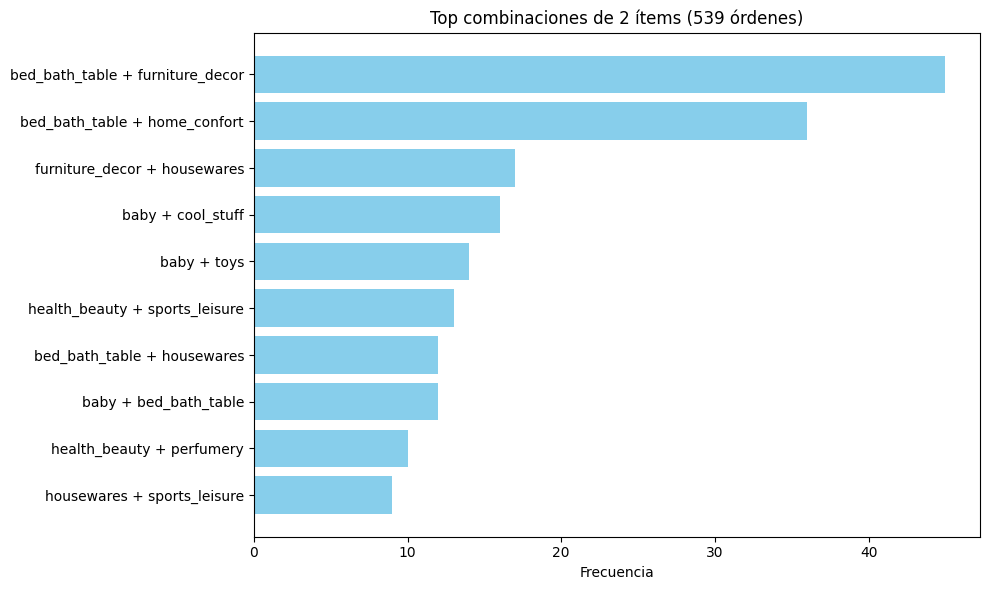

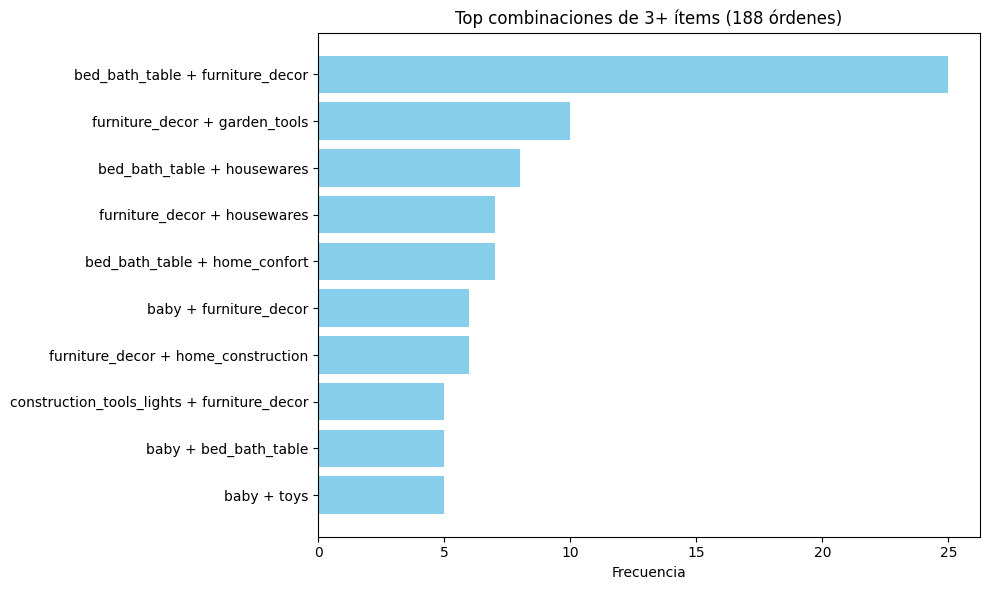

In [19]:
# Traducir nombres de categorías
category_map = dict(zip(category_translation['product_category_name'], category_translation['product_category_name_english']))

# Unir productos con sus categorías
order_items_with_cat = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# Contar cuántos ítems hay por pedido
order_size = order_items.groupby('order_id').size().reset_index(name='num_items')

# Agregar esa información al dataset principal
order_items_with_cat = order_items_with_cat.merge(order_size, on='order_id', how='left')

# Función para obtener combinaciones de categorías distintas
def get_category_combinations(df):
    combos = (
        df.groupby('order_id')['product_category_name']
        .apply(lambda x: sorted(set(x.dropna())))
    )
    combos = combos[combos.apply(len) >= 2]
    
    pair_counts = {}
    for cats in combos:
        for pair in combinations(cats, 2):
            translated_pair = tuple(sorted([category_map.get(cat, cat) for cat in pair]))
            pair_counts[translated_pair] = pair_counts.get(translated_pair, 0) + 1

    result = (
        pd.DataFrame([
            {"category_pair": f"{a} + {b}", "count": c}
            for (a, b), c in pair_counts.items()
        ])
        .sort_values(by="count", ascending=False)
        .reset_index(drop=True)
    )
    return result, combos.shape[0]

# Pedidos con exactamente 2 ítems
orders_2_items = order_items_with_cat[order_items_with_cat['num_items'] == 2]
combos_2, total_2 = get_category_combinations(orders_2_items)

# Pedidos con 3 o más ítems
orders_3plus_items = order_items_with_cat[order_items_with_cat['num_items'] >= 3]
combos_3plus, total_3plus = get_category_combinations(orders_3plus_items)

# Mostrar resultados
print(f"Top combinaciones en pedidos de 2 ítems (basado en {total_2} órdenes con 2 ítems y 2+ categorías):")
print(combos_2.head(10))

print(f"\nTop combinaciones en pedidos de 3 o más ítems (basado en {total_3plus} órdenes con 3+ ítems y 2+ categorías):")
print(combos_3plus.head(10))

# Graficar resultados
def plot_top_combinations(df, title):
    top = df.head(10)
    plt.figure(figsize=(10, 6))
    plt.barh(top['category_pair'][::-1], top['count'][::-1], color='skyblue')
    plt.xlabel('Frecuencia')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_top_combinations(combos_2, f"Top combinaciones de 2 ítems ({total_2} órdenes)")
plot_top_combinations(combos_3plus, f"Top combinaciones de 3+ ítems ({total_3plus} órdenes)")


Categorías donde se compraron 2 ítems iguales en una misma orden:
                category  count
0         bed_bath_table   1004
1        furniture_decor    803
2         sports_leisure    572
3  computers_accessories    548
4          health_beauty    506
5             housewares    487
6           garden_tools    391
7              telephony    230
8          watches_gifts    209
9                   auto    198


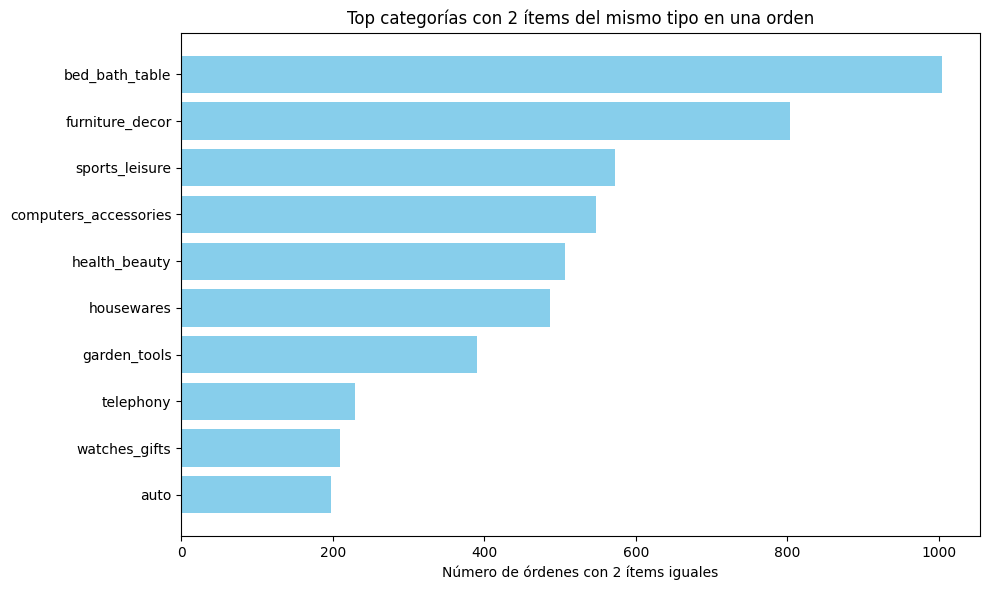

In [21]:
# 1. Filtrar órdenes con exactamente 2 ítems
orders_2_items = order_items_with_cat[order_items_with_cat['num_items'] == 2]

# 2. Agrupar por order_id y verificar si ambos productos tienen la misma categoría
same_category_orders = (
    orders_2_items.groupby('order_id')['product_category_name']
    .apply(lambda x: x.dropna().tolist())
    .reset_index(name='categories')
)

# 3. Filtrar solo las órdenes donde los dos ítems tienen la misma categoría
same_category_orders['is_same'] = same_category_orders['categories'].apply(lambda x: len(set(x)) == 1)
same_category_orders = same_category_orders[same_category_orders['is_same']]

# 4. Extraer la categoría que se repite (como es la misma, usamos el primero)
same_category_orders['category'] = same_category_orders['categories'].apply(lambda x: x[0])

# 5. Contar cuántas veces aparece cada categoría duplicada en una orden
same_category_counts = same_category_orders['category'].value_counts().reset_index()
same_category_counts.columns = ['product_category_name', 'count']

# 6. Traducir categorías
category_translation = pd.read_csv("data/product_category_name_translation.csv")
same_category_counts = same_category_counts.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

# 7. Reemplazar por nombre en inglés si está disponible
same_category_counts['category'] = same_category_counts['product_category_name_english'].fillna(same_category_counts['product_category_name'])

# 8. Mostrar resultados
print("Categorías donde se compraron 2 ítems iguales en una misma orden:")
print(same_category_counts[['category', 'count']].head(10))

# 9. Graficar
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(same_category_counts['category'][:10], same_category_counts['count'][:10], color='skyblue')
plt.xlabel("Número de órdenes con 2 ítems iguales")
plt.title("Top categorías con 2 ítems del mismo tipo en una orden")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Costo promedio del flete (freight_value) por número de ítems en la orden

In [29]:
print("Costo promedio del flete por número de ítems en la orden:")
order_items.groupby('order_id').agg({
    'freight_value': 'sum',
    'order_item_id': 'count'
}).groupby('order_item_id')['freight_value'].mean()


Costo promedio del flete por número de ítems en la orden:


order_item_id
1      20.368021
2      37.211457
3      55.151014
4      74.084554
5      89.860539
6     116.813535
7     123.718636
8     179.565000
9     310.740000
10    231.140000
11    323.267500
12    187.830000
13     96.070000
14    148.470000
15    130.650000
20    245.600000
21    164.370000
Name: freight_value, dtype: float64

#### Valor promedio del producto por tamaño de orden (price vs num_items)

In [27]:
print("Valor promedio del producto por tamaño de orden")
order_items.groupby('order_id').agg({
    'price': 'mean',
    'order_item_id': 'count'
}).groupby('order_item_id')['price'].mean()


Valor promedio del producto por tamaño de orden


order_item_id
1     130.378012
2      87.547858
3      79.194894
4      79.394262
5      76.700980
6      69.116936
7      69.676429
8     265.670000
9      86.833333
10    145.632000
11     71.328409
12     46.305000
13     29.990000
14     44.495000
15     58.245000
20     99.350000
21      1.514286
Name: price, dtype: float64

#### Tiempo promedio de entrega (order_delivered_customer_date - order_purchase_timestamp) por tamaño de orden

In [28]:
print("Tiempo promedio de entrega por tamaño de orden")
orders['delivery_time'] = (
    pd.to_datetime(orders['order_delivered_customer_date']) - 
    pd.to_datetime(orders['order_purchase_timestamp'])
).dt.days

orders.merge(order_size, on='order_id')\
      .groupby('num_items')['delivery_time'].mean()


Tiempo promedio de entrega por tamaño de orden


num_items
1     12.175196
2     11.361964
3     11.158499
4     11.777778
5     11.580311
6     11.418848
7     11.181818
8     13.125000
9      8.666667
10     9.625000
11    17.750000
12    10.400000
13    11.000000
14    11.000000
15    16.500000
20    10.000000
21    14.000000
Name: delivery_time, dtype: float64

#### Porcentaje de órdenes con productos repetidos (2 o más ítems de la misma categoría)

In [30]:
print("Porcentaje de órdenes con productos repetidos")
num_orders_with_repeats = len(same_category_orders)
total_orders_2items = len(order_items_with_cat[order_items_with_cat['num_items'] == 2]['order_id'].unique())
porcentaje = num_orders_with_repeats / total_orders_2items * 100
print(porcentaje)

Porcentaje de órdenes con productos repetidos
91.79084619478446
